# Libraries

In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# Read dataset

### Excel

In [6]:
filename_excel = '../dataset/dataset_2_rv3.xlsx'

In [7]:
df = pd.read_excel(filename_excel)
colunas_manter = [
                     'Diâmetro da armadura (mm)', 'Resistência do aço - fy (MPa)',
                     'Resistência à tração do concreto (MPa)', 'Cobrimento (mm)',
                     'Taxa de armadura conforme MC2020',
                     'Tensão na armadura menos tension stiffening variável (MPa)',
                     'Output: w_exp (mm)'
                 ]
df_filtrado = df[colunas_manter]
df_filtrado

,Diâmetro da armadura (mm),Resistência do aço - fy (MPa),Resistência à tração do concreto (MPa),Cobrimento (mm),Taxa de armadura conforme MC2020,Tensão na armadura menos tension stiffening variável (MPa),Output: w_exp (mm)
0,20.0,500,4.120341,25.0,0.021300,120.527746,0.16
1,20.0,500,4.120341,25.0,0.021300,223.847983,0.23
2,20.0,500,4.120341,25.0,0.021300,242.052198,0.24
3,20.0,500,4.120341,25.0,0.021300,325.147190,0.27
4,20.0,500,4.120341,25.0,0.021300,447.784457,0.35
...,...,...,...,...,...,...,...
336,28.7,276,2.576579,38.0,0.046242,213.143867,0.19
337,28.7,276,2.576579,38.0,0.046242,245.038321,0.22
338,35.8,276,2.547836,38.0,0.067478,150.918822,0.17
339,35.8,276,2.756373,38.0,0.067478,108.349173,0.19


In [8]:
df_filtrado.to_excel('crack_dataset_2.xlsx', index=False)

In [9]:
df_filtrado.columns

Index(['Diâmetro da armadura (mm)', 'Resistência do aço - fy (MPa)',
       'Resistência à tração do concreto (MPa)', 'Cobrimento (mm)',
       'Taxa de armadura conforme MC2020',
       'Tensão na armadura menos tension stiffening variável (MPa)',
       'Output: w_exp (mm)'],
      dtype='object')

In [10]:
x = df_filtrado[colunas_manter[:-1]]
x

,Diâmetro da armadura (mm),Resistência do aço - fy (MPa),Resistência à tração do concreto (MPa),Cobrimento (mm),Taxa de armadura conforme MC2020,Tensão na armadura menos tension stiffening variável (MPa)
0,20.0,500,4.120341,25.0,0.021300,120.527746
1,20.0,500,4.120341,25.0,0.021300,223.847983
2,20.0,500,4.120341,25.0,0.021300,242.052198
3,20.0,500,4.120341,25.0,0.021300,325.147190
4,20.0,500,4.120341,25.0,0.021300,447.784457
...,...,...,...,...,...,...
336,28.7,276,2.576579,38.0,0.046242,213.143867
337,28.7,276,2.576579,38.0,0.046242,245.038321
338,35.8,276,2.547836,38.0,0.067478,150.918822
339,35.8,276,2.756373,38.0,0.067478,108.349173


In [11]:
y = df_filtrado[['Output: w_exp (mm)']]
y

,Output: w_exp (mm)
0,0.16
1,0.23
2,0.24
3,0.27
4,0.35
...,...
336,0.19
337,0.22
338,0.17
339,0.19


### Divided in three groups

In [12]:
y = y.squeeze()
y_class = pd.qcut(y, q=3, labels=["low", "medium", "high"])
df_labels = pd.DataFrame({"w": y, "class_w": y_class})
df_labels.head()

,w,class_w
0,0.16,low
1,0.23,medium
2,0.24,medium
3,0.27,medium
4,0.35,high


### Count the groups

In [13]:
df_labels["class_w"].value_counts()

class_w
low       139
high      107
medium     95
Name: count, dtype: int64

### Crack width classification

In [14]:
low = df_labels[df_labels["class_w"] == "low"]
medium = df_labels[df_labels["class_w"] == "medium"]
high = df_labels[df_labels["class_w"] == "high"]

In [15]:
low.describe()
text_low = rf"$w_{{min}}$: {low['w'].min():.2f}, $w_{{max}}$: {low['w'].max():.2f}"
text_low

'$w_{min}$: 0.14, $w_{max}$: 0.20'

In [16]:
medium.describe()
text_medium = rf"$w_{{min}}$: {medium['w'].min():.2f}, $w_{{max}}$: {medium['w'].max():.2f}"
text_medium

'$w_{min}$: 0.21, $w_{max}$: 0.27'

In [17]:
high.describe()
text_high = rf"$w_{{min}}$: {high['w'].min():.2f}, $w_{{max}}$: {high['w'].max():.2f}"
text_high

'$w_{min}$: 0.28, $w_{max}$: 0.79'

# Run TSNE ML

In [18]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
tsne = TSNE(
                n_components=2,
                perplexity=30,
                learning_rate="auto",
                init="pca",
                random_state=42
            )

x_tsne = tsne.fit_transform(x_scaled)
tsne_df = pd.DataFrame(
                            x_tsne,
                            columns=["tSNE1", "tSNE2"],
                            index=x.index
                       )

tsne_df["class_crack"] = y_class.values
tsne_df

,tSNE1,tSNE2,class_crack
0,2.275023,-9.474108,low
1,1.991337,-9.699045,medium
2,1.923887,-9.764508,medium
3,1.562909,-10.211260,medium
4,0.584606,-11.461076,high
...,...,...,...
336,24.562521,5.081111,low
337,24.036860,4.610953,medium
338,27.440289,3.989482,low
339,27.568974,4.158788,low


In [19]:
tsne_df.loc[tsne_df["class_crack"] == "low", "class_w"] = text_low
tsne_df.loc[tsne_df["class_crack"] == "medium", "class_w"] = text_medium
tsne_df.loc[tsne_df["class_crack"] == "high", "class_w"] = text_high
tsne_df

,tSNE1,tSNE2,class_crack,class_w
0,2.275023,-9.474108,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
1,1.991337,-9.699045,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
2,1.923887,-9.764508,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
3,1.562909,-10.211260,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
4,0.584606,-11.461076,high,"$w_{min}$: 0.28, $w_{max}$: 0.79"
...,...,...,...,...
336,24.562521,5.081111,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
337,24.036860,4.610953,medium,"$w_{min}$: 0.21, $w_{max}$: 0.27"
338,27.440289,3.989482,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"
339,27.568974,4.158788,low,"$w_{min}$: 0.14, $w_{max}$: 0.20"


In [20]:
tsne_df.to_excel('TSNE_dataset_2.xlsx', index=False)  

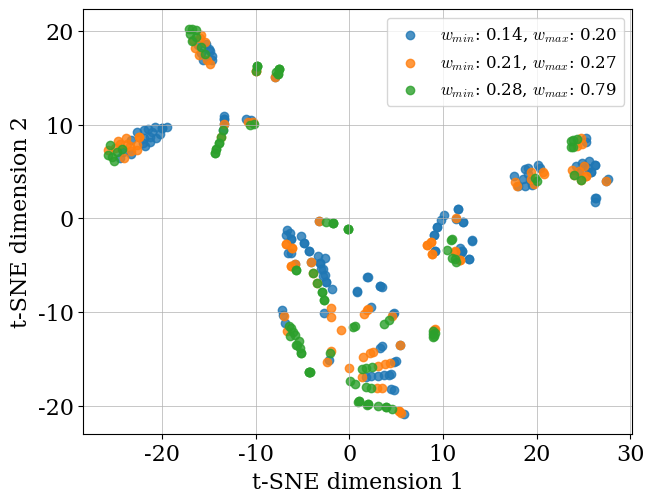

In [21]:
dpi = 600               # Change as you wish
name = 'TSNE_dataset_2' # Change as you wish

b_cm = 18                       # Change as you wish
h_cm = 14                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm


label_x = 't-SNE dimension 1' # Change as you wish
label_y = 't-SNE dimension 2'     # Change as you wish
size_label = 16                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 16                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

for classe in tsne_df["class_w"].unique():
    subset = tsne_df[tsne_df["class_w"] == classe]
    ax.scatter(
        subset["tSNE1"],
        subset["tSNE2"],
        label=classe,
        alpha=0.8
    )
    ax.legend(fontsize=12, loc='upper right')
# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [22]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(x_tsne, y_class)
sil

-0.016657106578350067